In [3]:
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten
from keras.layers import Conv2D,MaxPooling2D
import os
from matplotlib import pyplot as plt
import numpy as np

In [4]:
IMG_HEIGHT=64
IMG_WIDTH = 64
batch_size=64


In [7]:
train_data_dir='E:\\Capstone\\Dataset\\Gray_Img\\train'
validation_data_dir='E:\\Capstone\\Dataset\\Gray_Img\\test'

In [8]:
train_datagen = ImageDataGenerator(
					rescale=1./255,
					rotation_range=30,
					shear_range=0.3,
					zoom_range=0.3,
					horizontal_flip=True,
					fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
					train_data_dir,
					color_mode='grayscale',
					target_size=(IMG_HEIGHT, IMG_WIDTH),
					batch_size=batch_size,
					class_mode='categorical',
					shuffle=True)

validation_generator = validation_datagen.flow_from_directory(
							validation_data_dir,
							color_mode='grayscale',
							target_size=(IMG_HEIGHT, IMG_WIDTH),
							batch_size=batch_size,
							class_mode='categorical',
							shuffle=True)

Found 16125 images belonging to 7 classes.
Found 4032 images belonging to 7 classes.


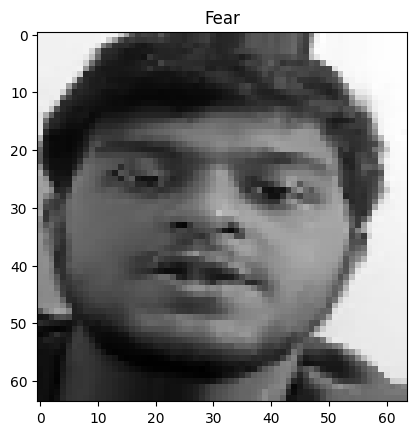

In [9]:
class_labels=['Angry','Disgust', 'Fear', 'Happy','Neutral','Sad','Surprise']

img, label = train_generator.__next__()

import random

i=random.randint(0, (img.shape[0])-1)
image = img[i]
labl = class_labels[label[i].argmax()]
plt.imshow(image[:,:,0], cmap='gray')
plt.title(labl)
plt.show()

In [6]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64,64,1)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(7, activation='softmax'))

model.compile(optimizer = 'adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 60, 60, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 30, 30, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 30, 30, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 128)       0         
 g2D)                                                

In [7]:
train_path = 'E:\\Capstone\\Dataset\\Gray_Img\\train'
test_path = 'E:\\Capstone\\Dataset\\Gray_Img\\test'

In [8]:
num_train_imgs = 0
for root, dirs, files in os.walk(train_path):
    num_train_imgs += len(files)
    
num_test_imgs = 0
for root, dirs, files in os.walk(test_path):
    num_test_imgs += len(files)

In [9]:
epochs=50

history=model.fit(train_generator,
                steps_per_epoch=num_train_imgs//batch_size,
                epochs=epochs,
                validation_data=validation_generator,
                validation_steps=num_test_imgs//batch_size)

Epoch 1/50


251/251 [==============================] - 410s 2s/step - loss: 1.8885 - accuracy: 0.1745 - val_loss: 1.7739 - val_accuracy: 0.2746
Epoch 2/50
251/251 [==============================] - 171s 679ms/step - loss: 1.6112 - accuracy: 0.3418 - val_loss: 1.2524 - val_accuracy: 0.5005
Epoch 3/50
251/251 [==============================] - 176s 702ms/step - loss: 1.2469 - accuracy: 0.5025 - val_loss: 0.8555 - val_accuracy: 0.6508
Epoch 4/50
251/251 [==============================] - 172s 684ms/step - loss: 1.0120 - accuracy: 0.5904 - val_loss: 0.6584 - val_accuracy: 0.7478
Epoch 5/50
251/251 [==============================] - 173s 688ms/step - loss: 0.8498 - accuracy: 0.6632 - val_loss: 0.5277 - val_accuracy: 0.8075
Epoch 6/50
251/251 [==============================] - 169s 673ms/step - loss: 0.7440 - accuracy: 0.6991 - val_loss: 0.5250 - val_accuracy: 0.7812
Epoch 7/50
251/251 [==============================] - 171s 681ms/step - loss: 0.6710 - accuracy: 0.7299 - val_loss: 0.4185 - 

In [10]:
model.save('image_Conv2D_model_50_epochs.h5')

c:\Python10\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


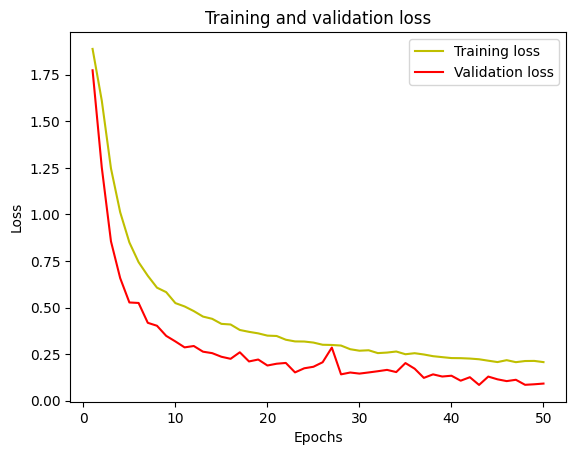

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

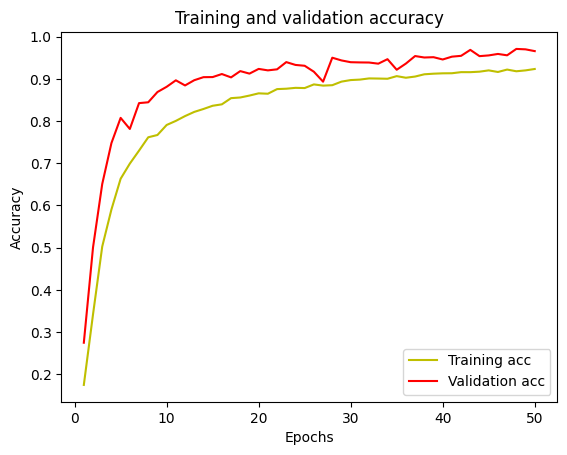

In [12]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

2/2 [==============================] - 0s 136ms/step
Accuracy =  0.953125


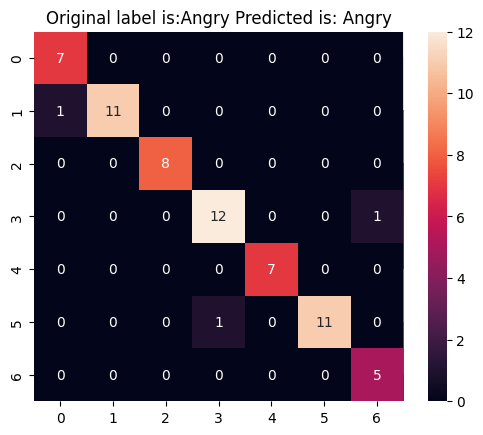

In [15]:
from keras.models import load_model

#Test the model
my_model = load_model('image_Conv2D_model_50_epochs.h5', compile=False)

#Generate a batch of images
test_img, test_lbl = validation_generator.__next__()
predictions=my_model.predict(test_img)

predictions = np.argmax(predictions, axis=1)
test_labels = np.argmax(test_lbl, axis=1)

from sklearn import metrics
print ("Accuracy = ", metrics.accuracy_score(test_labels, predictions))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predictions)
#print(cm)
import seaborn as sns
sns.heatmap(cm, annot=True)

class_labels=['Angry','Disgust', 'Fear', 'Happy','Neutral','Sad','Surprise']
#Check results on a few select images
n=random.randint(0, test_img.shape[0] - 1)
image = test_img[n]
orig_labl = class_labels[test_labels[n]]
pred_labl = class_labels[predictions[n]]
plt.imshow(image[:,:,0], cmap='gray')
plt.title("Original label is:"+orig_labl+" Predicted is: "+ pred_labl)
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad','surprise']  # Replace with your actual class names
report = classification_report(test_labels, predictions, target_names=class_names, labels=range(len(class_names)))
print(report)

              precision    recall  f1-score   support

       angry       0.88      1.00      0.93         7
     disgust       1.00      0.92      0.96        12
        fear       1.00      1.00      1.00         8
       happy       0.92      0.92      0.92        13
     neutral       1.00      1.00      1.00         7
         sad       1.00      0.92      0.96        12
    surprise       0.83      1.00      0.91         5

    accuracy                           0.95        64
   macro avg       0.95      0.97      0.95        64
weighted avg       0.96      0.95      0.95        64

